# ICS 235 Assignment 2
## Linear Regression, Gradient Descent, and Logistic Regression
# <font color="red">Due: 11:59 PM on Wednesday, October 7</font>

## Instructions

1. Name your notebook file using your last and first name.
    - For example, if your name is Harry Potter, rename the notebook file as `PotterHarry_2.ipynb` (the number at the end is the assignment number).
2. Only use the `.ipynb` file extension. Other formats (`.rtf`, `.zip`, `.docx`, `.pdf`) are not accepted.
3. The data file will be available to the instructor and the TA, so there is no need to upload it. Make sure you use the same filename given in the assignment.
4. Save the data file in your **working directory**.
5. **Do not modify or delete the provided code and the code cell.**
   - Do not add your own code to the existing code cell containing the provided code.
   - Keep the provided code unchanged so that it can be used as a reference and checked as intended.
7. Clean your code before submission.
    - If needed, provide clear documentation describing the purpose and use of every class or function you write.
    - Your submission should **show only the required outputs**.
8. **<font color='red'>IMPORTANT:</font>** Before submitting your homework:
   - Save the notebook.
   - Restart the kernel to clear its memory and **run the whole notebook top to bottom.** (`Kernel → Restart & Run All Cells`).
   - Confirm every cell completes without error and all outputs are visible.
9. Write your full name in the cell below.


### AI tools

You may use AI coding assistants as a learning aid, but **you must understand and be able to explain every line you submit**. You may be asked to do so. Submitting code you cannot explain is an academic integrity violation.
***

## Your Name: Denny Huang
***

# Getting Started

<font color='blue'>**Do not modify any of the provided code in this section. Run the code exactly as provided.**</font>
- If you are using Google Colab, you may add a **separate code cell** for loading the data. Do not add the data-loading code to the provied code cell.

## About the data

This assignment uses `pa2_beach_water_quality.csv`, a table of water-quality readings taken at six Oʻahu beaches.

> **This dataset is synthetic.** It was generated for instructional use in this course. The beaches are real places and the relationships are physically plausible, but no row corresponds to a real measurement, and nothing here should be used to judge whether any actual beach is safe.

The table has **640 rows** and **10 columns**:

| Column | Type | Description |
|---|---|---|
| `beach` | categorical | One of six Oʻahu beaches |
| `season` | categorical | `dry` or `wet` |
| `rain_24h_mm` | numerical | Rainfall in the previous 24 hours, in millimetres |
| `rain_72h_mm` | numerical | Rainfall in the previous 72 hours, in millimetres |
| `days_since_rain` | numerical | Days since the last measurable rain |
| `turbidity_ntu` | numerical | **Regression target.** Water cloudiness, in nephelometric turbidity units |
| `stream_flow_cfs` | numerical | Flow in the nearest stream, in cubic feet per second |
| `water_temp_c` | numerical | Water temperature, in °C |
| `tide_ft` | numerical | Tide height, in feet |
| `advisory` | binary | **Classification target.** 1 if a health advisory was posted, 0 otherwise |

## The two tasks

Storm runoff carries bacteria into coastal water, so after heavy rain the Department of Health may post an advisory telling people not to swim. This assignment asks two related questions about that process.

1. **Regression (Part 2).** How cloudy will the water be? Predict `turbidity_ntu` from the rainfall and stream conditions, using **linear regression** &mdash; fit both by the **closed-form solution** and by **gradient descent**.
2. **Classification (Part 3).** Will an advisory be posted? Predict `advisory` using **logistic regression**, and evaluate it with the binary classification metrics discussed in class.

The second task is where the assignment gets interesting. An advisory is posted on only about 18% of days, and you will find that a model can score well on accuracy while failing badly at the job it actually exists to do.

Download `pa2_beach_water_quality.csv` from Lamaku and save the file in your **working directory**.

## Importing packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility: use this constant everywhere a random_state is required.
RANDOM_STATE = 42

## Loading the dataset

In [2]:
water = pd.read_csv("pa2_beach_water_quality.csv")
water.head()

,beach,season,rain_24h_mm,rain_72h_mm,days_since_rain,turbidity_ntu,stream_flow_cfs,water_temp_c,tide_ft,advisory
0,Hanauma,dry,1.4,3.8,2,0.2,0.0,27.2,0.95,0
1,Haleiwa,wet,3.6,28.4,0,7.7,136.2,24.6,1.49,0
2,Waimanalo,wet,4.3,26.8,0,5.3,103.1,26.7,2.24,0
3,Waimanalo,wet,12.3,50.7,0,13.7,135.1,26.8,1.97,0
4,Kailua,dry,0.5,33.7,0,8.8,42.0,29.1,1.83,0


The next cell defines the column groups you will use throughout. Run it now.

In [3]:
# Conditions measured independently of the water itself. 
# These are the inputs available for BOTH tasks.
weather_features = ["rain_24h_mm", "rain_72h_mm", "days_since_rain",
                    "stream_flow_cfs", "water_temp_c", "tide_ft"]

categorical_features = ["beach", "season"]

REGRESSION_TARGET = "turbidity_ntu"     # Part 2
CLASSIFICATION_TARGET = "advisory"      # Part 3

***
# Exercises

This assignment has **three parts**, worth 100 points total.

Write your answer wherever you see a *`# YOUR CODE`* comment in a code cell or a **`YOUR ANSWER:`** prompt in a markdown cell. Some cells already contain code to get you started &mdash; **do not modify the provided code**. The point value of each question is given in parentheses after the question text.

| Part | Topic | Points |
|---|---|---|
| 1 | The data, cleaning, and two baselines | 30 |
| 2 | Linear regression and gradient descent | 34 |
| 3 | Logistic regression and classification metrics | 36 |

***
## Part 1: The Data, Cleaning, and Two Baselines (30 points)

Same discipline as Assignment 1: find out what you have, repair it, and work out what number each model
has to beat &mdash; before fitting anything.

### Question 1. Dataset structure (1 $\times$ 3 = 3 points)

1. Print the number of rows and columns as a readable sentence.
2. Display the column names with their data types and non-null counts.
3. Display the **first 8 rows**.

In [4]:
# YOUR CODE
rows, cols = water.shape
print(f"The dataframe has {rows} rows and {cols} columns.")

display(water.info())
display(water.head(8))

The dataframe has 640 rows and 10 columns.
<class 'pandas.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   beach            640 non-null    str    
 1   season           640 non-null    str    
 2   rain_24h_mm      640 non-null    float64
 3   rain_72h_mm      640 non-null    float64
 4   days_since_rain  640 non-null    int64  
 5   turbidity_ntu    626 non-null    float64
 6   stream_flow_cfs  628 non-null    float64
 7   water_temp_c     640 non-null    float64
 8   tide_ft          640 non-null    float64
 9   advisory         640 non-null    int64  
dtypes: float64(6), int64(2), str(2)
memory usage: 50.1 KB


None

,beach,season,rain_24h_mm,rain_72h_mm,days_since_rain,turbidity_ntu,stream_flow_cfs,water_temp_c,tide_ft,advisory
0,Hanauma,dry,1.4,3.8,2,0.2,0.0,27.2,0.95,0
1,Haleiwa,wet,3.6,28.4,0,7.7,136.2,24.6,1.49,0
2,Waimanalo,wet,4.3,26.8,0,5.3,103.1,26.7,2.24,0
3,Waimanalo,wet,12.3,50.7,0,13.7,135.1,26.8,1.97,0
4,Kailua,dry,0.5,33.7,0,8.8,42.0,29.1,1.83,0
5,Hanauma,wet,0.6,10.0,0,6.3,65.7,27.8,0.67,0
6,Waimanalo,dry,3.2,13.7,0,0.9,47.4,27.1,0.89,0
7,Ala Moana,wet,15.0,21.2,0,1.8,28.2,27.2,1.33,0


**Summary of the data**
- **Regression target:** `turbidity_ntu` &mdash; a continuous measurement of how cloudy the water is.
- **Classification target:** `advisory` &mdash; a 0/1 flag for whether a health advisory was posted.
- **Categorical columns:** `beach` (six nominal locations) and `season` (`dry` / `wet`).

That leaves six numerical weather and ocean measurements as features. Note that `advisory` is stored as an integer but is *not* a numerical feature &mdash; it is a label, and using it as an input to the regression in Part 2 would be a mistake.

### Question 2. Clean the categorical columns (2 + 1 + 2 + 2 = 7 points)

1. Print the value counts of **both** `beach` and `season`. How many **distinct labels** does each report?
2. In the answer cell, identify the labels that refer to the same real category but were recorded differently.
3. Create a **cleaned copy** of the DataFrame called `clean` in which both columns are standardized. Do **not** overwrite `water`.
   - Hint: `.str.strip()` removes stray whitespace; `.str.title()` and `.str.lower()` normalize capitalization. The two columns need different treatment &mdash; `beach` holds proper nouns, `season` does not.
   - Re-print both value counts and report the new number of distinct labels.
4. In the answer cell: how many rows were affected in total, and why does a handful of misspelled rows matter at all?

In [5]:
# YOUR CODE
print("Beach counts:")
print(water["beach"].value_counts())
print("Number of distinct beaches:", water["beach"].nunique())

print("\nSeason counts:")
print(water["season"].value_counts())
print("Number of distinct seasons:", water["season"].nunique())

clean = water.copy()

clean["beach"] = clean["beach"].str.strip().str.title().str.lower()
clean["season"] = clean["season"].str.strip().str.title().str.lower()

print("Beach counts:")
print(clean["beach"].value_counts())
print("Number of distinct beaches:", clean["beach"].nunique())

print("\nSeason counts:")
print(clean["season"].value_counts())
print("Number of distinct seasons:", clean["season"].nunique())

Beach counts:
beach
Waikiki      153
Ala Moana    143
Kailua       110
Waimanalo     85
Haleiwa       79
Hanauma       63
waikiki        7
Name: count, dtype: int64
Number of distinct beaches: 7

Season counts:
season
dry    373
wet    262
Wet      5
Name: count, dtype: int64
Number of distinct seasons: 3
Beach counts:
beach
waikiki      160
ala moana    143
kailua       110
waimanalo     85
haleiwa       79
hanauma       63
Name: count, dtype: int64
Number of distinct beaches: 6

Season counts:
season
dry    373
wet    267
Name: count, dtype: int64
Number of distinct seasons: 2


>**YOUR ANSWER:**
>
>**Q2.2:** In the beach column, there's a value 'waikiki' and 'Waikiki', these refer to the same category but were recorded differently. In the season column, there's a value 'wet' and 'Wet', these refer to the same category but were recorded differently.
>
>
>**Q2.4:** 12 rows were affected in total: 7 with beach == "waikiki" and 5 with season == "Wet". A handful of misspelled rows still matters because when we do hot-one encoding, it would treat those typos as separate categories, increasing the dimensionality of the dataset and potentially affecting the model's results.
>
>

### Question 3. Missing values (2 + 1 + 2 = 5 points)

1. Print the count and the percentage of missing values for every column that has any.
2. Report how many rows have at least one missing value.
3. In the answer cell: `turbidity_ntu` is the regression **target**. Explain why a missing value in the *target* is a different problem from a missing value in a *feature*, and say what you should do with those rows.

In [6]:
# YOUR CODE
missing = clean.isnull().sum()
missing_percent = clean.isnull().mean() * 100

print(missing)
print(missing_percent)

rows_missing_at_least_one = clean.isnull().any(axis=1).sum()

print("Rows that are missing at least one value:", rows_missing_at_least_one)



beach               0
season              0
rain_24h_mm         0
rain_72h_mm         0
days_since_rain     0
turbidity_ntu      14
stream_flow_cfs    12
water_temp_c        0
tide_ft             0
advisory            0
dtype: int64
beach              0.0000
season             0.0000
rain_24h_mm        0.0000
rain_72h_mm        0.0000
days_since_rain    0.0000
turbidity_ntu      2.1875
stream_flow_cfs    1.8750
water_temp_c       0.0000
tide_ft            0.0000
advisory           0.0000
dtype: float64
Rows that are missing at least one value: 26


>**YOUR ANSWER (Q3.3):** Missing a value in target is a different problem from a missing value in a feature because the target is the value we are using the regression to predict. If the target is missing, there is no known outcome to use for training the model and should be removed from the training data. Missing feature values can be imputed because the target value (hopefully) will still be known.

### Question 4. What drives turbidity? (3 + 2 = 5 points)

1. **Correlation** describes the strength and direction of a **linear relationship** between two numerical variables. Its value ranges from **−1 to +1**.
   - A value close to **+1** indicates a strong positive relationship: as one variable increases, the other tends to increase.
   - A value close to **−1** indicates a strong negative relationship: as one variable increases, the other tends to decrease.
   - A value close to **0** indicates little or no linear relationship.
   <br>
   The absolute value of the correlation tells us how strong the relationship is, regardless of its direction.

    **Important:** Correlation describes an association between two variables. It does not mean that one variable causes the other.

   - Compute the **correlation of every numerical column with `turbidity_ntu`**, excluding `turbidity_ntu` itself.
       - Hint: You can calculate the correlations using `DataFrame.corr()`. 
   - Sort the results from **strongest to weakest** based on the **absolute value** of the correlation.
   - Display the sorted results.<br><br>

2. In the answer cell: which three features look most useful for predicting turbidity, and does the physical story make sense? 

In [7]:
# YOUR CODE
correlation = abs(water.corr(numeric_only=True)["turbidity_ntu"].drop("turbidity_ntu").sort_values(ascending=False))

display(correlation)


rain_72h_mm        0.725935
stream_flow_cfs    0.602947
rain_24h_mm        0.530348
advisory           0.402117
tide_ft            0.026237
water_temp_c       0.110975
days_since_rain    0.189683
Name: turbidity_ntu, dtype: float64

>**YOUR ANSWER (Q4.2):**  rain_72h_mm, stream_flow_cfs, rain_24h_mm are the top 3 features that look the most useful for predicting turbidity. Yes, the physical story makes sense. More rainfall, especially over the previous 72 hours, can increase runoff into streams and coastal waters. That can carry sediment into the water, increasing turbidity. Higher stream flow can also transport more sediment, which explains its somewhat strong correlation with turbidity
>
>

### Question 5. Two baselines (3 + 3 + 4 = 10 points)

Every model needs a **baseline &mdash; a simple reference point that tells us what performance we should expect without using the features**. Regression and classification use different baselines because they predict different types of outcomes.

**<font color='blue'>For the remaining part of this assignment, use the train/test splits created in the provided code cell below.</font>**

1. **Regression baseline.** Using the provided Part 2 train/test split, fit a `DummyRegressor(strategy="mean")`. This baseline ignores all features and always predicts the **mean of the target in the training set**. Report its **RMSE** and **$R^2$** on the test set.
   - Hint: Use `mean_squared_error(y, pred)` and `r2_score(y, pred)` from `sklearn.metrics`. Calculate RMSE, by taking the square root of MSE with `np.sqrt(...)`.
2. **Classification baseline.** Using the provided Part 3 train/test split, fit a `DummyClassifier(strategy="most_frequent")`. This baseline ignores all features and always predicts the **most frequent class in the training set**. Report its **accuracy** on the test set.
3. In the answer cell, explain:
   - What does $R^2 = 0$ mean for the regression baseline?
   - Why should a classification baseline of approximately 82% accuracy make you cautious about using accuracy as the main performance metric for Part 3.

In [8]:
# ============================ PROVIDED SETUP — do not modify ============================
from sklearn.model_selection import train_test_split

# ---- Part 2 (regression): drop rows with a missing TARGET, keep all features ----
reg_data = clean.dropna(subset=[REGRESSION_TARGET]).copy()
X_reg = reg_data[weather_features + categorical_features]
y_reg = reg_data[REGRESSION_TARGET]

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE)

# ---- Part 3 (classification): all rows; turbidity is now a FEATURE ----
clf_features = weather_features + ["turbidity_ntu"]
X_clf = clean[clf_features + categorical_features]
y_clf = clean[CLASSIFICATION_TARGET]

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=RANDOM_STATE, stratify=y_clf)

print(f"Part 2 regression    : {len(Xr_tr)} train, {len(Xr_te)} test "
      f"({len(clean) - len(reg_data)} rows dropped for missing target)")
print(f"Part 3 classification: {len(Xc_tr)} train, {len(Xc_te)} test")
print(f"advisory rate in training data: {y_clf.mean():.3f}")
# =======================================================================================

Part 2 regression    : 469 train, 157 test (14 rows dropped for missing target)
Part 3 classification: 480 train, 160 test
advisory rate in training data: 0.180


In [9]:
# YOUR CODE
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(Xr_tr, yr_tr)

pred = dummy.predict(Xr_te)

mse = mean_squared_error(yr_te, pred)
r2 = r2_score(yr_te, pred)
rmse = np.sqrt(mse)

print(f"Baseline RMSE: {rmse:.3f}")
print(f"Baseline R^2: {r2:.3f}")

Baseline RMSE: 3.611
Baseline R^2: -0.001


>**YOUR ANSWER (Q5.3):** An $R^2 = 0$ means that the baseline model is no better than just predicting the mean value of the target for every data point entry. A classficiation baseline of approximately 82% accuracy should make you cautious about using accuracy as the main performance metric because classes could be imbalanced. A model can have a high accuracy by simply predicting the majority class correct and might not reflect how well the model performs on the minority class. Therefore, accuracy alone is not a metric we should rely on how well a model performs.
>

***
## Part 2: Linear Regression and Gradient Descent (34 points)

Now predict `turbidity_ntu`. You will fit linear regression in two different ways: first using the closed-form solution, and then using gradient descent. Both approaches are trying to find the coefficients that minimize the same squared-error objective, but they reach the solution differently. 

You will also compare the models with and without feature scaling. Pay particular attention to how feature scaling affects gradient descent and whether it affects the closed-form solution.

### Question 1. Fit a linear regression (2 + 1 + 2 + 2 = 7 points)

1. Build a `ColumnTransformer` named `reg_preprocessor` that applies:
   - to `weather_features`: a `SimpleImputer(strategy="median")` then a `StandardScaler()`;
   - to `categorical_features`: a `OneHotEncoder(handle_unknown="ignore")`.
2. Wrap it with a `LinearRegression()` in a `Pipeline` called `linreg`, and fit on the training data.
3. Report **RMSE** and **$R^2$** on the test set, alongside the baseline from Part 1.
4. Calculate the percentage improvement in RMSE compared with the baseline RMSE. Report the result as a *percentage rounded to one decimal place*.
   - Hint: Use the formula:<br>
     $$
     \frac{\text{baseline RMSE} - \text{model RMSE}}{\text{baseline RMSE}} \times 100
     $$

In [10]:
# YOUR CODE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("weather", Pipeline([("impute", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), weather_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

linreg = Pipeline([("preprocessor", reg_preprocessor), (("model"), LinearRegression())])
linreg.fit(Xr_tr, yr_tr)

lin_model_pred = linreg.predict(Xr_te)
lin_model_mse = mean_squared_error(yr_te, lin_model_pred)
lin_model_rmse = np.sqrt(lin_model_mse) 
lin_model_r2 = r2_score(yr_te, lin_model_pred)

rmse_improvement = ((rmse - lin_model_rmse) / rmse) * 100

print(f"Baseline RMSE: {rmse:.3f}")
print(f"Baseline R^2: {r2:.3f}")

print(f"Linreg RMSE: {lin_model_rmse:.3f}")
print(f"Linreg R^2: {lin_model_r2:.3f}")

print(f"RMSE improvement over baseline: {rmse_improvement:.1f}")

Baseline RMSE: 3.611
Baseline R^2: -0.001
Linreg RMSE: 2.573
Linreg R^2: 0.492
RMSE improvement over baseline: 28.8


### Question 2. Read the coefficients (3 + 4 = 7 points)

1. Extract the fitted coefficients together with their feature names, and print them sorted by *absolute value*, from largest to smallest. Also, print the intercept.
   - Hint: `linreg.named_steps[...].get_feature_names_out()` gives the features names in the same order as the coefficients, while `linreg.named_steps[...].coef_` gives the coefficient values.
2. In the answer cell:
   - Which feature has the largest coefficient in absolute value, and what does its coefficient mean in plain words?
   - The numerical features were **standardized** before fitting. Explain why standardization makes the coefficients more directly comparable to one another.
   - What would happen if you tried to rank the importance of numerical features using their *unstandardized* coefficients? Explain why a larger coefficient would not necessarily mean that the feature is more important.

In [44]:
# YOUR CODE
# Extract the fitted coefficients together with their feature names, and print them sorted by *absolute value*, from largest to smallest. Also, print the intercept.
preprocessor = linreg.named_steps["preprocessor"]
model = linreg.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
coefs = model.coef_

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df["coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("coefficient", ascending=False)


print(f"Model Intercept: {model.intercept_:.3f}")
print(coef_df)

Model Intercept: 6.672
                         feature  coefficient
1           weather__rain_72h_mm     2.695435
8     categorical__beach_hanauma     0.488968
7     categorical__beach_haleiwa     0.477924
11  categorical__beach_waimanalo     0.438246
12       categorical__season_dry     0.323115
13       categorical__season_wet     0.323115
9      categorical__beach_kailua     0.296134
5               weather__tide_ft     0.174404
10    categorical__beach_waikiki     0.155334
3       weather__stream_flow_cfs     0.139981
0           weather__rain_24h_mm     0.112197
4          weather__water_temp_c     0.101443
6   categorical__beach_ala moana     0.077178
2       weather__days_since_rain     0.053994


>**YOUR ANSWER (Q2.2):** weather__rain_72h_mm has the largest coefficient in absolute value. In plain words, its coefficient means that 1 standard deviation increase in rainfall over the previous 72 hours is associated with an increase of 2.695435 units in the model’s predicted outcome, holding the other features constant. The standardization makes the coefficients more directly comparable to one another because it helps rescale features into a similar scale, (0 mean, and 1 stdev). This makes the magnitudes of the coefficients more comparable. If we tried to rank the importance of numerical features using unstandardized coefficients, features with larger units or larger measurement scales could have larger or smaller coefficients simply because of the units they are measured in. Therefore, a larger unstandardized coefficient would not necessarily mean that the feature is more important.
>

### Question 3. The same model by gradient descent (5 + 4 = 9 points)

`LinearRegression` solves for the optimum directly using linear algebra. `SGDRegressor`, in contrast, approaches the same objective using **gradient descent**: it repeatedly updates the model parameters by taking steps in the direction that redues the prediction error.

1. Using the same train/test split and `reg_preprocessor` from the previous questions, compare `SGDRegressor` with the closed-form `LinearRegression` result from Question 1.
   - Loop through the following learning rates (`eta0`): `0.0001`, `0.001`, `0.01`, and `0.1`
   - Inside the loop, build and fit a pipeline named `sgd` that:
       - reuses `reg_preprocessor` as the preprocessing step; and
       - uses `SGDRegressor` with `eta0` set to the current learning rate, `learning_rate="constant"`, `max_iter=5000`, `penalty=None`, and `random_state=RANDOM_STATE`.
   - Report the test $R^2$ for each learning rate, alongside the closed-form $R^2$ result from Question 1. Report all values to *three* decimal places.
2. In the answer cell:
   - Which learning rates produce a model that converges to a good solution?
   - What happens when the learning rate is `0.1`?
   - Explain what `eta0` controls in gradient descent and why choosing an appropriate value matters.

In [47]:
# YOUR CODE
from sklearn.linear_model import SGDRegressor

learning_rates = [0.0001, 0.001, 0.01, 0.1]

for eta0 in learning_rates:
    sgd = Pipeline([
        ("preprocessor", reg_preprocessor),
        ("model", SGDRegressor(
            eta0=eta0,
            learning_rate="constant",
            max_iter=5000,
            penalty=None,
            random_state=RANDOM_STATE,
        )),
    ])

    # Larger R^2 = better
    sgd.fit(Xr_tr, yr_tr)
    sgd_pred = sgd.predict(Xr_te)
    sgd_r2 = r2_score(yr_te, sgd_pred)
    print(f"SGD eta={eta0} -> test R_2: {sgd_r2:3f}")


SGD eta=0.0001 -> test R_2: 0.487920
SGD eta=0.001 -> test R_2: 0.492363
SGD eta=0.01 -> test R_2: 0.458613
SGD eta=0.1 -> test R_2: 0.238590


<!--SOLUTION-->
>**YOUR ANSWER (Q3.2):** 0.0001, 0.001, 0.01 all produce a model that converges to a good solution. 0.001 performed the best amongst the 3, with an R^2 value of 0.492363. When the learning rate is 0.1, the R^2 value drops to 0.238590. This could mean that the learning rate is too large, causing the gradient descent to overshoot everytime and not finding the optimal solution. eta0 controls the initial learning rate. Choosing an appropriate eta0 value matters because having a learning rate too small can cause training to take very long and having a learning rate too large can cause us to overshoot, and never converge at a good / optimal solution.
>

### Question 4. Why gradient descent needs scaling &mdash; and the closed form does not (2 + 5 + 4 = 11 points)

In this question, you will compare the effect of feature scaling on closed-form linear regression and gradient descent.

1. Build a second preprocessor named `reg_preprocessor_unscaled`. It should be identical to `reg_preprocessor`, except that it **does not include `StandardScaler`**. Keep the imputer and the one-hot encoder unchanged.
2. Fit the following **four** models and report the **test $R^2$** for each, rounded to *four* decimal places. Keep all other model settings the same so that the only difference is whether the numerical features are scaled. For `SGDRegressor`, use the same parameter settings as in Question 3.
   - `LinearRegression` **with** scaling
   - `LinearRegression` **without** scaling
   - `SGDRegressor(eta0=0.01)` **with** scaling
   - `SGDRegressor(eta0=0.01)` **without** scaling
3. In the answer cell, explain the pattern in the four $R^2$ values. Why is one of these four results catastrophic while another is completely unaffected? What does this comparison tell you about when feature scaling is optional and when it is important?

In [48]:
# YOUR CODE

"""
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("weather", Pipeline([("impute", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), weather_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
"""
reg_preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("weather", SimpleImputer(strategy="median"), weather_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# linear reg
linreg = Pipeline([("preprocessor", reg_preprocessor), (("model"), LinearRegression())])
linreg_unscale = Pipeline([("preprocessor_unscaled", reg_preprocessor_unscaled), (("model"), LinearRegression())])

# sgd reg
sgd = Pipeline([
        ("preprocessor", reg_preprocessor),
        ("model", SGDRegressor(
            eta0=0.01,
            learning_rate="constant",
            max_iter=5000,
            penalty=None,
            random_state=RANDOM_STATE,
        )),
    ])

sgd_unscale = Pipeline([
        ("preprocessor_unscaled", reg_preprocessor_unscaled),
        ("model", SGDRegressor(
            eta0=0.01,
            learning_rate="constant",
            max_iter=5000,
            penalty=None,
            random_state=RANDOM_STATE,
        )),
    ])

# fitting models
linreg.fit(Xr_tr, yr_tr)
linreg_unscale.fit(Xr_tr, yr_tr)
sgd.fit(Xr_tr, yr_tr)
sgd_unscale.fit(Xr_tr, yr_tr)

print("LinearRegression with scaling:",
      round(linreg.score(Xr_te, yr_te), 4))

print("LinearRegression without scaling:",
      round(linreg_unscale.score(Xr_te, yr_te), 4))

print("SGDRegressor eta0=0.01 with scaling:",
      round(sgd.score(Xr_te, yr_te), 4))

print("SGDRegressor eta0=0.01 without scaling:",
      round(sgd_unscale.score(Xr_te, yr_te), 4))

LinearRegression with scaling: 0.4919
LinearRegression without scaling: 0.4919
SGDRegressor eta0=0.01 with scaling: 0.4586
SGDRegressor eta0=0.01 without scaling: -9.238215072930275e+25


>**YOUR ANSWER (Q4.3):** The 4 R^2 values show that feature scaling had little to no effect on the LinearRegression model, but a large effect on the SGDRegressor model. The catastrophic result occurs because SGD uses gradient based updates, and the unscaled numerical features have different magnitudes. With the same learning rate, some gradient updates can become extremely large, causing the optimization to overshoot and fail to converge to a good solution. This comparison tells me that for gradient descent models, scaling is very important because gradient descent is sensitive to the relative sizes of the input features. Whereas feature scaling  is optional for the LinearRegression model because ols directly solves for the coefficients rather than relying on iterative gradient descent steps. 
>

***
## Part 3: Logistic Regression and Classification Metrics (36 points)

Now the question that matters operationally: **will an advisory be posted?**

Remember the baseline from Part 1: predicting **"no advisory" every day gives 82% accuracy**.

### Question 1. Fit a logistic regression (2 + 1 + 1 + 2 = 6 points)

1. Build a `ColumnTransformer` named `clf_preprocessor` using `clf_features` (the weather columns
   **plus** `turbidity_ntu`) and `categorical_features`. Note that `clf_features` and `categorical_features` are defined in the code provided earlier. Apply the same **impute $\rightarrow$ scale $\rightarrow$ one-hot encode** treatment used in Part 2.
2. Wrap the preprocessor with `LogisticRegression(max_iter=5000)` in a pipeline named `logreg`, and fit the pipeline using the training data, `Xc_tr` and `yc_tr`, created in the provided code earlier.
3. Report **test accuracy** and compare it with the **82% baseline**.
4. In the answer cell, explain why it is legitimate to use `turbidity_ntu` as a feature in this classification task even though it was the target in Part 2. What information about the timing or availability of a feature would make its use a **data leak**?

In [58]:
# YOUR CODE
from sklearn.linear_model import LogisticRegression

clf_preprocessor = ColumnTransformer(
    transformers=[
        ("weather", Pipeline([("impute", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), clf_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

logreg = Pipeline([("preprocessor", clf_preprocessor), (("model"), LogisticRegression(max_iter=5000))])
logreg.fit(Xc_tr, yc_tr)

y_pred = logreg.predict(Xc_te)

test_accuracy = logreg.score(Xc_te, yc_te)
print(f"Test accuracy: {test_accuracy * 100:.2f}")

Test accuracy: 85.62


>**YOUR ANSWER (Q1.4):** It is legitimate to use turbidity_ntu as a feature in this classification task even thought it was the target in part 2 because turbidity_ntu is no longer the target value and is an available input feature used to predict the classification target, so there is no problem with using it. Using a feature would become a data leak if that feature contains information that would not have been available at the time the prediction is supposed to be made. 
>

### Question 2. Look past the accuracy (2 + 1 + 3 + 3 = 9 points)

The test accuracy you just reported is a few points above the baseline. Now examine **how the model is making its predictions**.

1. Print the **confusion matrix**, wrapped in a labeled `pd.DataFrame` so the rows and columns are clearly identified as `no advisory` and `advisory`.
2. Print the **classification report** with `digits=3`.
3. Report explicitly. (Note that `advisory` is the positive class in this problem.)
   - How many advisories were in the test set?
   - How many advisories did the model **correctly identify**?
   - How many advisories did the model **miss**?
   - What is the model's **recall for the advisory class**?
4. In the answer cell:
   - Explain what the reported recall value means in plain language.
   - The model has roughly **86% accuracy**, compared with the **82% baseline**. Based on the confusion matrix and classification report, is 86% accuracy a good result? Explain why or why not, considering how well the model identifies advisories rather than looking at accuracy alone.
   - Which error is more consequential in this application: a **false alarm** or a **missed advisory**? Explain your reasoning in terms of the consequences of each error.

In [70]:
# YOUR CODE
from sklearn.metrics import confusion_matrix, classification_report

labels=[0,1]
label_names = ["no advisory", "advisory"]
cm = confusion_matrix(yc_te, y_pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=pd.Index(label_names, name="Actual"),
    columns=pd.Index(label_names, name="Predicted")
    )

tn, fp, fn, tp = cm.ravel()

print(cm_df)
print("")
print(classification_report(yc_te, y_pred, target_names=label_names, digits=3))

print("Advisories in test set:", tp + fn)
print("Advisories correctly identified:", tp)
print("Advisories missed:", fn)
print("Advisory recall:", tp / (tp + fn))

Predicted    no advisory  advisory
Actual                            
no advisory          127         4
advisory              19        10

              precision    recall  f1-score   support

 no advisory      0.870     0.969     0.917       131
    advisory      0.714     0.345     0.465        29

    accuracy                          0.856       160
   macro avg      0.792     0.657     0.691       160
weighted avg      0.842     0.856     0.835       160

Advisories in test set: 29
Advisories correctly identified: 10
Advisories missed: 19
Advisory recall: 0.3448275862068966


>**YOUR ANSWER (Q2.4):** The reported recall value means that the model correctly identifies about 34.48% of actual advisories. Based on the confusion matrix and classification report, an 86% accuracy is not a good result because it was able to predict the majority class (no advisory), missing the actual advisories (it correctly identifies only 10 out of 29 advisories and misses 19). In this application, a missed advisory is more consequential because people may swim when an advisory exists (dangerous water conditions), which may cause physical harm and dangerous consequences. A false alarm would just a beach closure or cause inconvenience, but in this case, this inconvenience is not as concerning as people actually getting hurt.
>

### Question 3. Move the threshold (1 + 3 + 2 + 3 = 9 points)

`predict()` labels a day an `advisory` when the predicted probability is at least **0.5**. This 0.5 threshold is a default choice, not a rule that must always be used.

1. Get the predicted probabilities for the `advisory` class with:
```python
   logreg.predict_proba(Xc_te)[:, 1].
```
2. For each of the thresholds,`0.1`, `0.2`, `0.3`, `0.5`, and `0.7`, report:
   - **precision**;
   - **recall**;
   - the number of **missed advisories**; and
   - the number of **false alarms**.
3. Plot the **precision–recall curve**.
   - Hint: `precision_recall_curve(y_true, probabilities)` returns `(precision, recall, thresholds)`.
   - Plot **recall on the x-axis** and **precision on the y-axis**.
   - Label the axes and add a title.
4. In the answer cell, choose **one of the thresholds above** that you would actually deploy. **Justify** your choice using the observed trade-off between missed advisories and false alarms. What does the beach gain by using your chosen threshold, and what does it give up?

For threshold = 0.1:
  Precision: 0.371
  Recall: 0.793
  Missed advisories: 6
  False alarms: 39
For threshold = 0.2:
  Precision: 0.459
  Recall: 0.586
  Missed advisories: 12
  False alarms: 20
For threshold = 0.3:
  Precision: 0.577
  Recall: 0.517
  Missed advisories: 14
  False alarms: 11
For threshold = 0.5:
  Precision: 0.714
  Recall: 0.345
  Missed advisories: 19
  False alarms: 4
For threshold = 0.7:
  Precision: 1.000
  Recall: 0.276
  Missed advisories: 21
  False alarms: 0


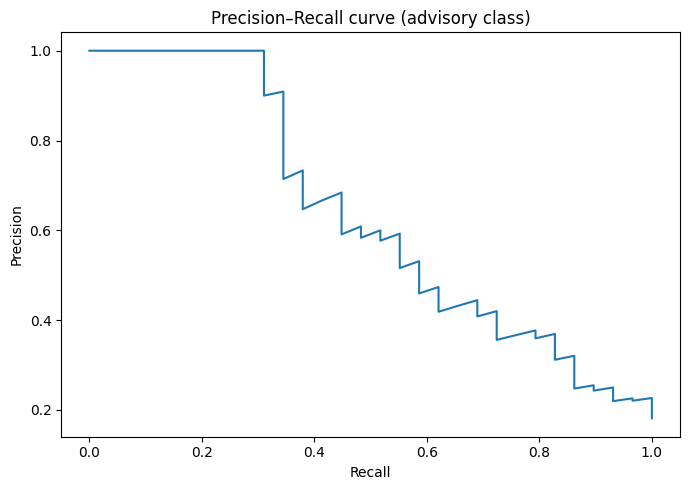

In [73]:
# YOUR CODE
from sklearn.metrics import precision_recall_curve, precision_score, recall_score

y_proba = logreg.predict_proba(Xc_te)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.5, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int) # convert T or F to 0s and 1s
    precision = precision_score(yc_te, y_pred_threshold)
    recall = recall_score(yc_te, y_pred_threshold)

    missed_advisories = ((yc_te == 1) & (y_pred_threshold == 0)).sum()
    false_alarms = ((yc_te == 0) & (y_pred_threshold == 1)).sum()

    print(f"For threshold = {threshold}:")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  Missed advisories: {missed_advisories}")
    print(f"  False alarms: {false_alarms}")

precision_val, recall_val, threshold_val = precision_recall_curve(yc_te, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(recall_val, precision_val)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve (advisory class)")
plt.tight_layout()
plt.show()

>**YOUR ANSWER (Q3.4):** Given the scenario we are in where we want to minimize missed advisories, I would pick threshold 0.1. This threshold minimizes missed advisories (6 missed) at the cost of a lot of false alarms (39). However, as we previously mentioned, the goal to minimize missed advisories is the most important in our application, making this justifiable. The trade off is that the beach will have more false alarms, which could lead to unnecessary beach closures and inconvenience. However, this is preferable to missing a real advisory and potentially putting swimmers at risk.
>

### Question 4. ROC and AUC (2 + 1 + 3 = 6 points)

1. Plot the **ROC curve**, with false-positive rate on the x-axis and true-positive rate on the y-axis. Include the diagonal **no-skill reference line**. Add axes labels, a title, and a legend.
2. Report the model's **ROC AUC**.
3. In the answer cell:
   - What does AUC measure that accuracy does not?
   - Why is AUC *threshold-independent*?
   - For this particular problem, which is more informative: the **ROC curve** or the **precision–recall curve**? Explain your choice in terms of the class imbalance and the relative importance of identifying advisories.

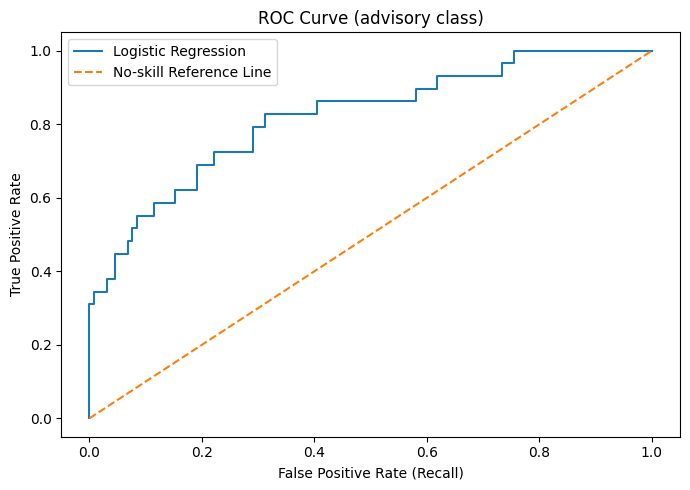

In [77]:
# YOUR CODE
from sklearn.metrics import roc_curve

fpr, tpr, scores = roc_curve(yc_te, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], "--", label="No-skill Reference Line")
plt.xlabel("False Positive Rate (Recall)")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (advisory class)")
plt.legend()
plt.tight_layout()
plt.show()


>**YOUR ANSWER (Q4.3):** The AUC measures how well the model can distinguish between advisories and no advisories across all classification thresholds, whereas accuracy only tells us how many predictions were correct at one particular threshold. AUC is threshold independent because it considers the models performance across all thresholds, rather than just one. For this particular problem, the precision-recall curve is more informative because it focuses specifically on precision and recall for the advisory class, which is more important here because our main goal is to identify as many actual advisories as possible and minimize missed advisories. The ROC curve can look  good when the majority class dominates, even if the model does a poor job identifying the minority class.

### Question 5. What raises the risk? (3 + 3 = 6 points)

1. Extract the fitted coefficients with their feature names and print them sorted by **absolute value**. Also, print the intercept.
2. In the answer cell:
   - Which **three features have the largest positive coefficients** and therefore most strongly increase the model's predicted probability of an advisory? Does the physical story make sense?
   - Logistic regression coefficients are on the **log-odds (logit) scale**. Explain what a coefficient of +1 means, and why you cannot interprete it as "adds 1 to the probability".

In [83]:
# YOUR CODE
feature_names = logreg.named_steps["preprocessor"].get_feature_names_out()
coefs = logreg.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)


print(f"Model Intercept: {logreg.named_steps['model'].intercept_[0]:.3f}")
print(coef_df[["feature", "coefficient"]])


Model Intercept: -2.096
                         feature  coefficient
1           weather__rain_72h_mm     0.695682
7   categorical__beach_ala moana     0.655867
9     categorical__beach_hanauma    -0.532303
10     categorical__beach_kailua    -0.326122
3       weather__stream_flow_cfs     0.315800
6         weather__turbidity_ntu     0.289756
5               weather__tide_ft     0.287316
0           weather__rain_24h_mm     0.234326
8     categorical__beach_haleiwa     0.205105
4          weather__water_temp_c     0.094630
13       categorical__season_dry    -0.076917
2       weather__days_since_rain    -0.076744
14       categorical__season_wet     0.076214
12  categorical__beach_waimanalo    -0.057295
11    categorical__beach_waikiki     0.054044


>**YOUR ANSWER (Q5.2):** The weather__rain_72h_mm, categorical__beach_ala moana, and weather__stream_flow_cfs features have the largest positive coefficients. The physical story makes sense because more rainfall over the previous 72 hours and higher stream flow could reasonably be associated with a greater chance of an advisory because rain can wash contaminants into the beach. A logistic regression coefficient of +1 means that holding the other features constant, a one unit increase in that feature increases the log odds of an advisory by 1. It does not mean that the probability of an advisory increases by 1, because logistic regression converts log odds to probability in a nonlinear way.
>